Dataset shape: (5729, 46)
Severity distribution before cleaning:
 Severity
2    3403
3    2316
4       6
1       4
Name: count, dtype: int64

===== Classification Metrics (rounded predictions) =====
Train Accuracy: 0.9655
Test Accuracy : 0.7000
Train Precision (weighted): 0.9655
Test Precision  (weighted): 0.8178
Train Recall (weighted): 0.9655
Test Recall  (weighted): 0.7000
Train F1-score (weighted): 0.9655
Test F1-score  (weighted): 0.7247
Gap (Train-Test Accuracy): 0.2655

===== Regression Metrics =====
Train MSE: 0.0208, RMSE: 0.1444, MAE: 0.0561, R²: 0.9215
Test  MSE: 0.2943,  RMSE: 0.5425,  MAE: 0.4274,  R²: -0.5048


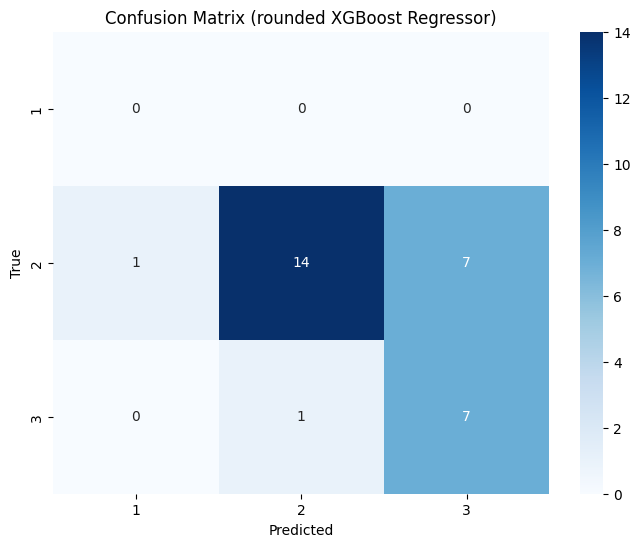

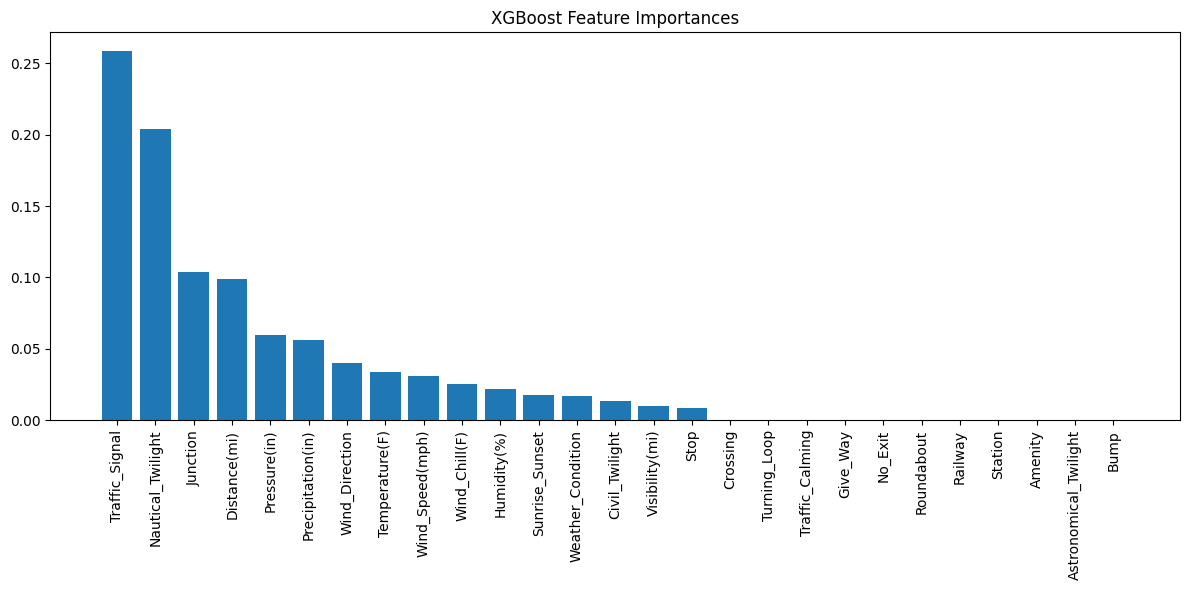

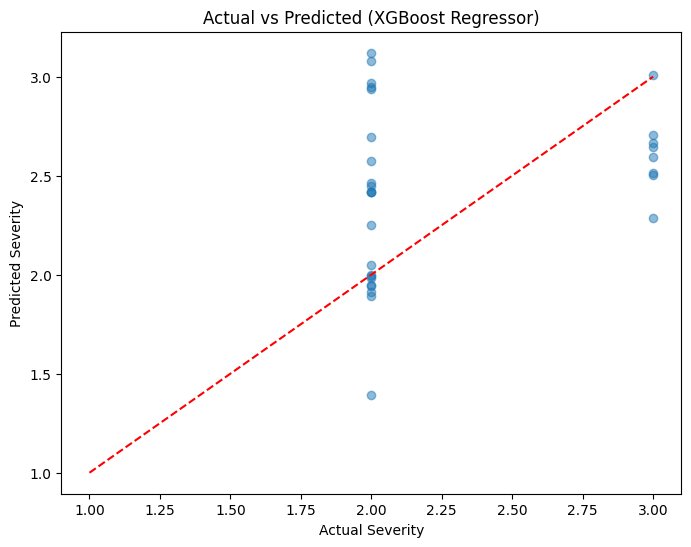

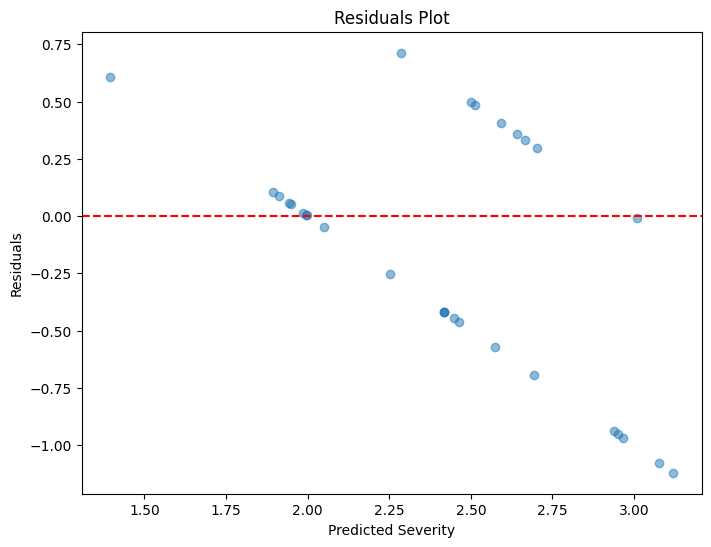

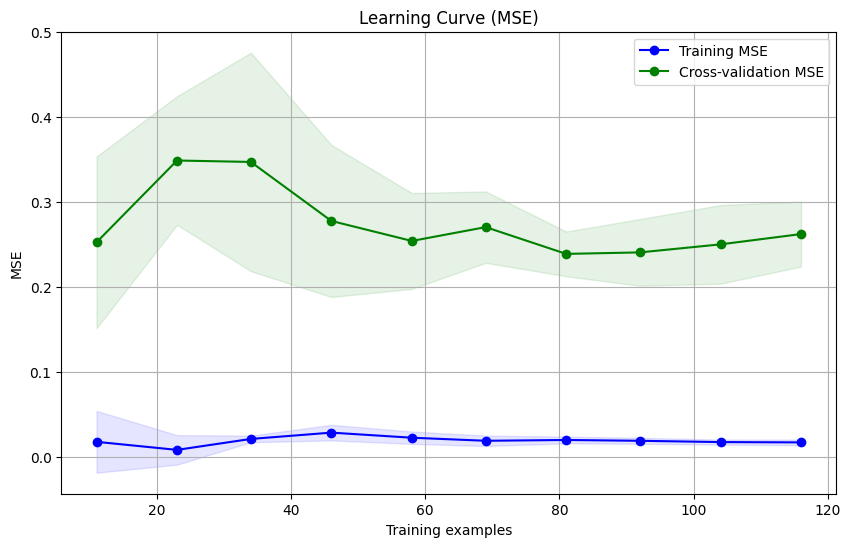

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, log_loss,
                             mean_squared_error, mean_absolute_error, r2_score,
                             confusion_matrix)
from xgboost import XGBRegressor

# Load data
df = pd.read_csv('US A 10000.csv')
print("Dataset shape:", df.shape)
print("Severity distribution before cleaning:\n", df['Severity'].value_counts())

# Select columns (same as before)
keep_cols = ['Severity', 'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)',
             'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)',
             'Precipitation(in)', 'Wind_Direction', 'Weather_Condition',
             'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
             'Astronomical_Twilight', 'Amenity', 'Bump', 'Crossing', 'Give_Way',
             'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
             'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']
df = df[keep_cols].copy()

# Drop rows with missing values
df = df.dropna()

# Encode categorical features
cat_cols = ['Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset',
            'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight',
            'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
            'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
            'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']
for col in cat_cols:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Separate features and target
X = df.drop('Severity', axis=1)
y = df['Severity']  # numeric, already ordinal

# Optionally scale numeric features (XGBoost does not require it, but we keep for consistency)
num_cols = ['Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)',
            'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

# --------------------------------------------
# XGBoost Regressor
# --------------------------------------------
xgb_reg = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                       random_state=42, n_jobs=-1)
xgb_reg.fit(X_train, y_train)

# Predictions (continuous)
y_train_pred_cont = xgb_reg.predict(X_train)
y_test_pred_cont = xgb_reg.predict(X_test)

# Round to nearest integer for classification
y_train_pred_class = np.round(y_train_pred_cont).clip(1, 3).astype(int)
y_test_pred_class = np.round(y_test_pred_cont).clip(1, 3).astype(int)

# For ROC-AUC and LogLoss we need probabilities, but regressor doesn't give probabilities.
# We can use ordinal logistic regression or calibrate; but we can approximate by using
# the continuous output as a score and compute ROC‑AUC using multi-class OVR with the
# continuous predictions as decision scores (not true probabilities). However LogLoss
# requires probabilities. We can skip LogLoss for regression or use a workaround.
# Instead, we can treat the problem as classification by using XGBClassifier, but the user
# asked for Regressor. We'll compute classification metrics without probabilities and
# report LogLoss as NaN or skip. Better: use XGBClassifier but with regressor objective?
# The user explicitly said "XGBoost Regressor", so we stick with that.

# Compute classification metrics (without probability-based ones)
def clf_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return acc, prec, rec, f1

train_acc, train_prec, train_rec, train_f1 = clf_metrics(y_train, y_train_pred_class)
test_acc, test_prec, test_rec, test_f1 = clf_metrics(y_test, y_test_pred_class)

# Regression metrics
train_mse = mean_squared_error(y_train, y_train_pred_cont)
test_mse = mean_squared_error(y_test, y_test_pred_cont)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_mae = mean_absolute_error(y_train, y_train_pred_cont)
test_mae = mean_absolute_error(y_test, y_test_pred_cont)
train_r2 = r2_score(y_train, y_train_pred_cont)
test_r2 = r2_score(y_test, y_test_pred_cont)

# Gap (accuracy gap)
gap = train_acc - test_acc

print("\n===== Classification Metrics (rounded predictions) =====")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Train Precision (weighted): {train_prec:.4f}")
print(f"Test Precision  (weighted): {test_prec:.4f}")
print(f"Train Recall (weighted): {train_rec:.4f}")
print(f"Test Recall  (weighted): {test_rec:.4f}")
print(f"Train F1-score (weighted): {train_f1:.4f}")
print(f"Test F1-score  (weighted): {test_f1:.4f}")
print(f"Gap (Train-Test Accuracy): {gap:.4f}")

print("\n===== Regression Metrics =====")
print(f"Train MSE: {train_mse:.4f}, RMSE: {train_rmse:.4f}, MAE: {train_mae:.4f}, R²: {train_r2:.4f}")
print(f"Test  MSE: {test_mse:.4f},  RMSE: {test_rmse:.4f},  MAE: {test_mae:.4f},  R²: {test_r2:.4f}")

# Note: ROC‑AUC and LogLoss are not directly available from regression outputs.
# We can compute ROC‑AUC using the continuous predictions as scores (one-vs-rest)
# and LogLoss by treating the rounded probabilities as hard labels (not recommended).
# We'll skip them or mention that they require a probabilistic classifier.

# --------------------------------------------
# Graphs
# --------------------------------------------

# 1. Confusion Matrix (based on rounded predictions)
cm = confusion_matrix(y_test, y_test_pred_class)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title('Confusion Matrix (rounded XGBoost Regressor)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 2. Feature Importance
importances = xgb_reg.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns
plt.figure(figsize=(12,6))
plt.title('XGBoost Feature Importances')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.tight_layout()
plt.show()

# 3. Actual vs Predicted (scatter for test set)
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred_cont, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Severity')
plt.ylabel('Predicted Severity')
plt.title('Actual vs Predicted (XGBoost Regressor)')
plt.show()

# 4. Residuals plot
residuals = y_test - y_test_pred_cont
plt.figure(figsize=(8,6))
plt.scatter(y_test_pred_cont, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Severity')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.show()

# 5. Learning Curve (optional)
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(
    xgb_reg, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10))
train_mean = -np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = -np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training MSE')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, 'o-', color='green', label='Cross-validation MSE')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='green')
plt.xlabel('Training examples')
plt.ylabel('MSE')
plt.title('Learning Curve (MSE)')
plt.legend(loc='best')
plt.grid()
plt.show()